# Week 5 — Function 5: Bayesian Optimisation (4D)

In [7]:
# Cell 2: Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [8]:
# Cell 3: Load data and inspect
# Function 5: Chemical process yield (unimodal), 4D input, Maximise

X = np.load('../data/function_5/initial_inputs.npy')
Y = np.load('../data/function_5/initial_outputs.npy')

print(f'Input  shape : {X.shape}   (n_samples x n_dimensions)')
print(f'Output shape : {Y.shape}  (n_samples,)')
print()

# Sort descending by Y value
X_list = list(X)
Y_list = list(Y)
pairs = sorted(zip(Y_list, X_list), reverse=True)
Y_sorted = [p[0] for p in pairs]
X_sorted = [p[1] for p in pairs]

print('=' * 78)
print('  All observations (sorted descending by Y)')
print('=' * 78)
for i, (y_val, x_val) in enumerate(zip(Y_sorted, X_sorted)):
    marker = '  <-- best' if i == 0 else ''
    print(f'  [{i+1:2d}]  X = [{x_val[0]:.6f}, {x_val[1]:.6f}, {x_val[2]:.6f}, {x_val[3]:.6f}]   Y = {y_val:+.6e}{marker}')
print('=' * 78)

best_Y = Y_sorted[0]
best_X = np.array(X_sorted[0])
print(f'\n  Best Y*  = {best_Y:.6e}')
print(f'  Best X*  = [{best_X[0]:.8f}, {best_X[1]:.8f}, {best_X[2]:.8f}, {best_X[3]:.8f}]')

Input  shape : (20, 4)   (n_samples x n_dimensions)
Output shape : (20,)  (n_samples,)

  All observations (sorted descending by Y)
  [ 1]  X = [0.224189, 0.846480, 0.879484, 0.878516]   Y = +1.088860e+03  <-- best
  [ 2]  X = [0.119879, 0.862540, 0.643331, 0.849804]   Y = +4.316128e+02
  [ 3]  X = [0.438933, 0.774092, 0.378167, 0.933696]   Y = +3.558068e+02
  [ 4]  X = [0.836478, 0.193610, 0.663893, 0.785649]   Y = +2.583705e+02
  [ 5]  X = [0.463442, 0.630025, 0.107906, 0.957644]   Y = +2.332236e+02
  [ 6]  X = [0.352356, 0.322242, 0.116979, 0.473113]   Y = +1.095719e+02
  [ 7]  X = [0.511142, 0.817957, 0.728710, 0.112354]   Y = +7.972913e+01
  [ 8]  X = [0.683432, 0.118663, 0.829046, 0.567577]   Y = +7.843439e+01
  [ 9]  X = [0.191447, 0.038193, 0.607418, 0.414584]   Y = +6.444344e+01
  [10]  X = [0.583973, 0.147243, 0.348097, 0.428615]   Y = +6.442015e+01
  [11]  X = [0.306889, 0.316878, 0.622634, 0.095399]   Y = +6.347672e+01
  [12]  X = [0.553621, 0.667350, 0.323806, 0.814870]   

In [9]:
# Cell 4: Fit GP with log-transformed Y

# Log-transform to handle extreme scale differences across observations
Y_fit = np.log(np.abs(Y) + 1e-300)

# Fixed RBF kernel (course style — no ConstantKernel, no optimisation)
kernel = RBF(length_scale=0.1, length_scale_bounds='fixed')
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
gp.fit(X, Y_fit)

print('=' * 62)
print('  GP Fitting Results')
print('=' * 62)
print(f'  Kernel                   : {gp.kernel_}')
print(f'  Log-marginal-likelihood  : {gp.log_marginal_likelihood_value_:.4f}')
print()

# Sanity check: predict at best known point
pred_mean, pred_std = gp.predict(best_X.reshape(1, -1), return_std=True)
actual_log = np.log(np.abs(best_Y) + 1e-300)
print('  Sanity check at best known X*:')
print(f'    X*                     = [{best_X[0]:.6f}, {best_X[1]:.6f}, {best_X[2]:.6f}, {best_X[3]:.6f}]')
print(f'    GP predicted mean      = {pred_mean[0]:.4f}  (log-space)')
print(f'    Actual log(|Y*|)       = {actual_log:.4f}  (log-space)')
print(f'    GP predicted std       = {pred_std[0]:.8f}')
print('=' * 62)

  GP Fitting Results
  Kernel                   : RBF(length_scale=0.1)
  Log-marginal-likelihood  : -198.8344

  Sanity check at best known X*:
    X*                     = [0.224189, 0.846480, 0.879484, 0.878516]
    GP predicted mean      = 6.9929  (log-space)
    Actual log(|Y*|)       = 6.9929  (log-space)
    GP predicted std       = 0.00001000


In [10]:
# Cell 5: UCB acquisition over random search (20,000 points)
# 4D grid search (10^4 = 10,000) is feasible but random search gives denser coverage

np.random.seed(42)
X_grid = np.random.uniform(0, 1, size=(20000, 4))  # shape (20000, 4)

# GP predictions across the random grid
post_mean, post_std = gp.predict(X_grid, return_std=True)

# UCB acquisition: mean + beta * std
beta = 2.5  #Higher beta = more exploration at early stage (Week 1, sparse data)
acquisition = post_mean + beta * post_std  # shape (20000,)

# Next query = grid point with highest UCB
best_idx = np.argmax(acquisition)
next_x   = X_grid[best_idx]
next_acq = acquisition[best_idx]

# Portal submission string
portal_string = f'{next_x[0]:.6f}-{next_x[1]:.6f}-{next_x[2]:.6f}-{next_x[3]:.6f}'

print('=' * 62)
print('  UCB Acquisition  (beta = 2.5, random search 20,000 pts)')
print('=' * 62)
print(f'  Grid size            : {len(X_grid)} points (random uniform)')
print(f'  Max UCB value        : {next_acq:.4f}')
print(f'  Next query point     : [{next_x[0]:.6f}, {next_x[1]:.6f}, {next_x[2]:.6f}, {next_x[3]:.6f}]')
print()
print('  Portal submission string:')
print(f'  >>> {portal_string} <<<')
print('=' * 62)

  UCB Acquisition  (beta = 2.5, random search 20,000 pts)
  Grid size            : 20000 points (random uniform)
  Max UCB value        : 7.5625
  Next query point     : [0.209005, 0.838746, 0.859156, 0.882439]

  Portal submission string:
  >>> 0.209005-0.838746-0.859156-0.882439 <<<


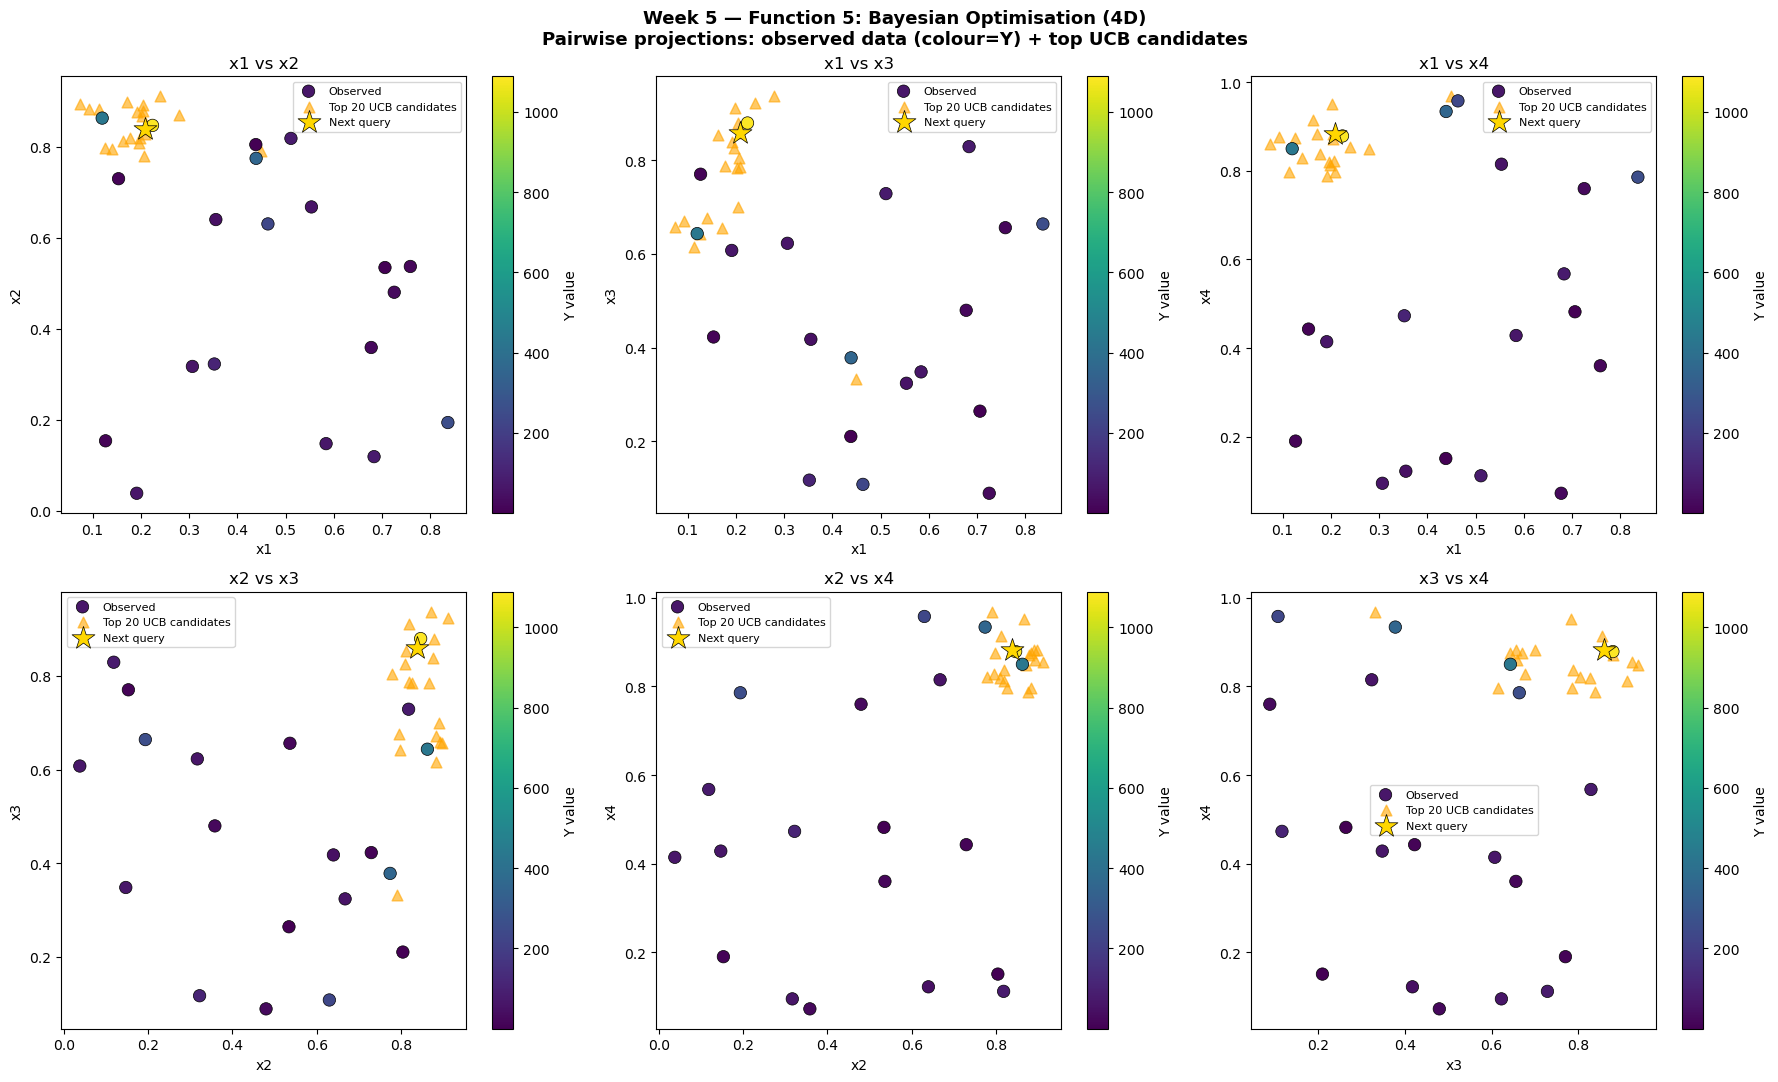

In [11]:
# Cell 6: Visualisation — pairwise scatter plots of observed data + top UCB candidates

# Top 20 candidates by UCB
top_idx = np.argsort(acquisition)[::-1][:20]
top_x   = X_grid[top_idx]

dim_labels = ['x1', 'x2', 'x3', 'x4']
pairs_to_plot = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for ax, (d_a, d_b) in zip(axes, pairs_to_plot):
    sc = ax.scatter(X[:, d_a], X[:, d_b], c=Y, cmap='viridis', s=80,
                    edgecolors='k', linewidths=0.5, zorder=5, label='Observed')
    plt.colorbar(sc, ax=ax, label='Y value')
    ax.scatter(top_x[:, d_a], top_x[:, d_b], c='orange', marker='^', s=60,
               alpha=0.6, zorder=4, label='Top 20 UCB candidates')
    ax.scatter(next_x[d_a], next_x[d_b], c='gold', marker='*', s=300, zorder=6,
               edgecolors='black', linewidths=0.5, label='Next query')
    ax.set_xlabel(dim_labels[d_a])
    ax.set_ylabel(dim_labels[d_b])
    ax.set_title(f'{dim_labels[d_a]} vs {dim_labels[d_b]}')
    ax.legend(fontsize=8)

plt.suptitle('Week 5 — Function 5: Bayesian Optimisation (4D)\nPairwise projections: observed data (colour=Y) + top UCB candidates',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Cell 7: Summary

print('=' * 62)
print('  SUMMARY — Bayesian Optimisation Results')
print('=' * 62)
print(f'  Function             : 4D Chemical Process Yield (unimodal)')
print(f'  Objective            : Maximise')
print(f'  Kernel               : RBF(length_scale=0.1, fixed)')
print(f'  Acquisition function : UCB  (beta = 2.5)')
print(f'  Y transform          : log(|Y| + 1e-300)')
print(f'  Grid search          : Random uniform (20,000 points)')
print()
print(f'  Current best X*      : [{best_X[0]:.6f}, {best_X[1]:.6f}, {best_X[2]:.6f}, {best_X[3]:.6f}]')
print(f'  Current best Y*      : {best_Y:.6e}')
print()
print(f'  Next query point     : [{next_x[0]:.6f}, {next_x[1]:.6f}, {next_x[2]:.6f}, {next_x[3]:.6f}]')
print()
print('  Portal submission string:')
print(f'  >>> {portal_string} <<<')
print('=' * 62)

  SUMMARY — Bayesian Optimisation Results
  Function             : 4D Chemical Process Yield (unimodal)
  Objective            : Maximise
  Kernel               : RBF(length_scale=0.1, fixed)
  Acquisition function : UCB  (beta = 2.5)
  Y transform          : log(|Y| + 1e-300)
  Grid search          : Random uniform (20,000 points)

  Current best X*      : [0.224189, 0.846480, 0.879484, 0.878516]
  Current best Y*      : 1.088860e+03

  Next query point     : [0.209005, 0.838746, 0.859156, 0.882439]

  Portal submission string:
  >>> 0.209005-0.838746-0.859156-0.882439 <<<
